In [27]:
#Top-down Dynamic Programming
def F1(n):
    if n == 0:
        return 0
    elif n == 1:
        return 1
    else:
        return F1(n-1) + F1(n-2)

In [28]:
F1(40)

102334155

In [29]:
#Top-down Dynamic Programming with Memoization
def F2_t(n, F):
    if F[n] == None:
        if n == 0:
            F[n] = 0
        elif n == 1:
            F[n] = 1
        else:
            F[n] = F2_t(n-1, F) + F2_t(n-2, F)
    return F[n]
def F2(n):
    return F2_t(n, [None] * (n + 1))

In [30]:
F2(40)

102334155

In [31]:
#  Iteration with Constant Storage
def F3(n):
    if n == 0:
        return 0
    elif n == 1:
        return 1
    else:
        a, b = 0, 1
        for _ in range(2, n+1):
            a, b = b, a + b
        return b

In [32]:
F3(95)

31940434634990099905

In [33]:
# F4
def mat_mul(m, n):
    r = [[0,0],[0,0]]
    r[0][0] = m[0][0]*n[0][0] + m[0][1]*n[1][0]
    r[0][1] = m[0][0]*n[0][1] + m[0][1]*n[1][1]
    r[1][0] = m[1][0]*n[0][0] + m[1][1]*n[1][0]
    r[1][1] = m[1][0]*n[0][1] + m[1][1]*n[1][1]
    return r

def mat_pow_recur(m, n):
    r = [[1,0],[0,1]]  #identity matrix
    if n>1:
        r = mat_pow_recur(m, n >> 1) # n//2
        r = mat_mul(r, r)
    if n % 2 == 1:
        r = mat_mul(r, m)
    return r

def F4(n):
    if n == 0:
        r = 0
    else:
        m = mat_pow_recur([[1,1],[1,0]], n-1)
        r = m[0][0]
    return r

In [34]:
F4(96)

51680708854858323072

In [35]:
# Squaring and recursive formula
def F5_t(n, F):
    if F[n] == None:
        if n == 0:
            F[n] = 0
        elif n == 1:
            F[n] = 1
        elif n == 2:
            F[n] = 1
        else:
            k = n >> 1
            f1 = F5_t(k, F)
            f2 = F5_t(k+1, F)
            if n % 2 == 0:
                F[n] = 2 * f1 * f2 - f1 * f1
            else:
                F[n] = f2 * f2 + f1 * f1
    return F[n]

def F5(n):
    return F5_t(n, [None]*(n+1))

In [36]:
F5(96)

51680708854858323072

In [37]:
test_min = [5, 7, 10, 12, 15, 18, 20, 22, 25, 30]
test_med = [32, 35, 38, 40, 45, 50, 55, 60, 65, 70]
test_high = [80, 120, 200, 300, 400, 500, 600, 700, 800, 900]
final_boss = [1000, 1500, 2000, 3000, 4000, 5000, 6000, 7000, 8500, 10000]

In [38]:
import time
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

def compute_print_and_plot_tests():

    # Define algorithm groups for each test set
    all_algorithms = [F1, F2, F3, F4, F5]
    algorithms_2_to_10 = [F2,F3, F4, F5]
    algorithms_final = [F3, F4, F4]
    algorithms_final_fast = [F4, F5]

    test_configs = [
        ("test_min", test_min, all_algorithms),
        ("test_med", test_med, algorithms_2_to_10),
        ("test_high", test_high, algorithms_2_to_10),
        ("final_boss", final_boss, algorithms_final),
        ("final_boss (fastest: F4, F5)", final_boss, algorithms_final_fast),
    ]

    for test_name, test_set, algorithms in test_configs:
        results = {alg.__name__: [] for alg in algorithms}

        print(f"\n{'='*80}")
        print(f"Running {test_name} with algorithms: {[alg.__name__ for alg in algorithms]}")
        print(f"{'='*80}")

        for n in test_set:
            for alg in algorithms:
                start_time = time.perf_counter_ns()
                alg(n)
                end_time = time.perf_counter_ns()
                elapsed_time_ns = end_time - start_time
                elapsed_time_s = elapsed_time_ns / 1e9
                results[alg.__name__].append((n, elapsed_time_s, elapsed_time_ns))

        # Plot results with high precision
        fig, ax = plt.subplots(figsize=(12, 7))
        for alg_name, times in results.items():
            ns = [n for n, t_s, t_ns in times]
            ts = [t_s for n, t_s, t_ns in times]
            ax.plot(ns, ts, marker='o', markersize=4, linewidth=1.5, label=alg_name)

        ax.set_xlabel('n', fontsize=12)
        ax.set_ylabel('Time (seconds)', fontsize=12)
        ax.set_title(f'Fibonacci Algorithm Performance - {test_name}', fontsize=14)
        ax.legend(loc='best', fontsize=10)
        ax.grid(True, which='both', linestyle='--', alpha=0.7)
        
        # Use scientific notation for y-axis
        ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
        ax.ticklabel_format(style='scientific', axis='y', scilimits=(0, 0))
        ax.yaxis.get_offset_text().set_fontsize(10)
        
        # Add minor gridlines for more precision
        ax.minorticks_on()
        ax.grid(True, which='minor', linestyle=':', alpha=0.4)
        
        plt.tight_layout()
        plt.show()
        
        # Print statistics summary
        print(f"\n--- Summary for {test_name} ---")
        for alg_name, times in results.items():
            ts = [t_s for n, t_s, t_ns in times]
            avg_time = sum(ts) / len(ts)
            min_time = min(ts)
            max_time = max(ts)
            print(f"{alg_name}: avg={avg_time:.15e}s, min={min_time:.15e}s, max={max_time:.15e}s")


Running test_min with algorithms: ['F1', 'F2', 'F3', 'F4', 'F5']


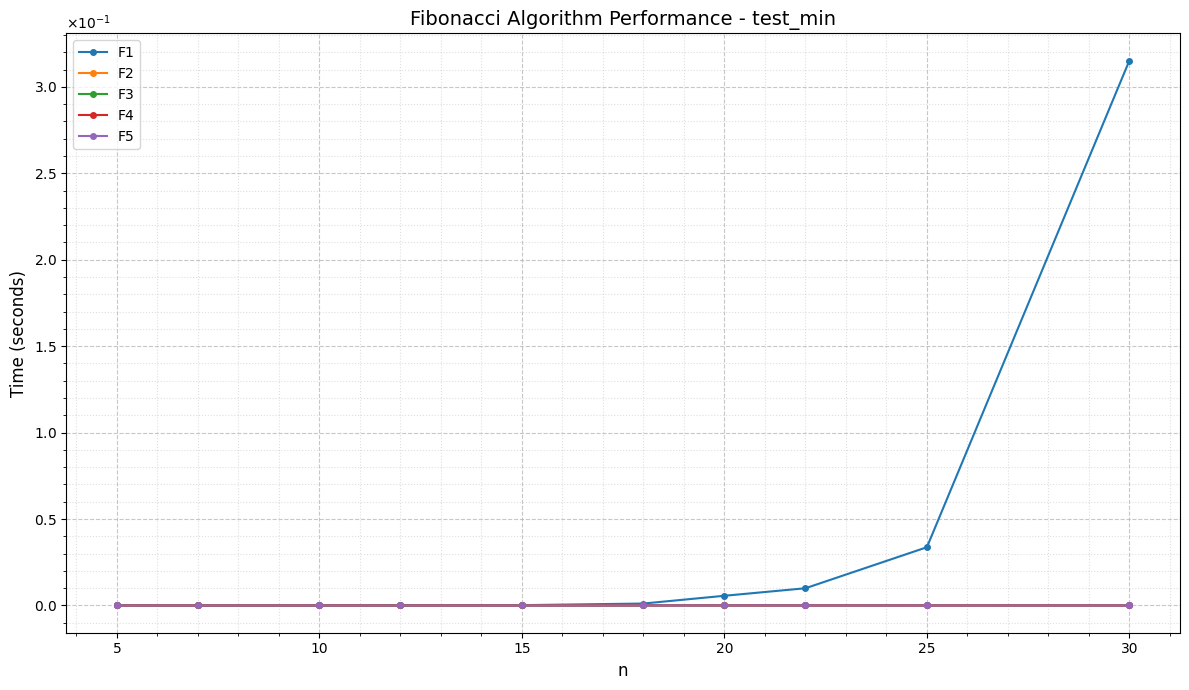


--- Summary for test_min ---
F1: avg=3.658926000000000e-02s, min=4.100000000000000e-06s, max=3.152302000000000e-01s
F2: avg=1.314000000000000e-05s, min=3.900000000000000e-06s, max=2.970000000000000e-05s
F3: avg=7.229999999999999e-06s, min=1.200000000000000e-06s, max=3.070000000000000e-05s
F4: avg=1.576000000000000e-05s, min=5.600000000000000e-06s, max=3.750000000000000e-05s
F5: avg=1.006000000000000e-05s, min=3.100000000000000e-06s, max=2.600000000000000e-05s

Running test_med with algorithms: ['F2', 'F3', 'F4', 'F5']


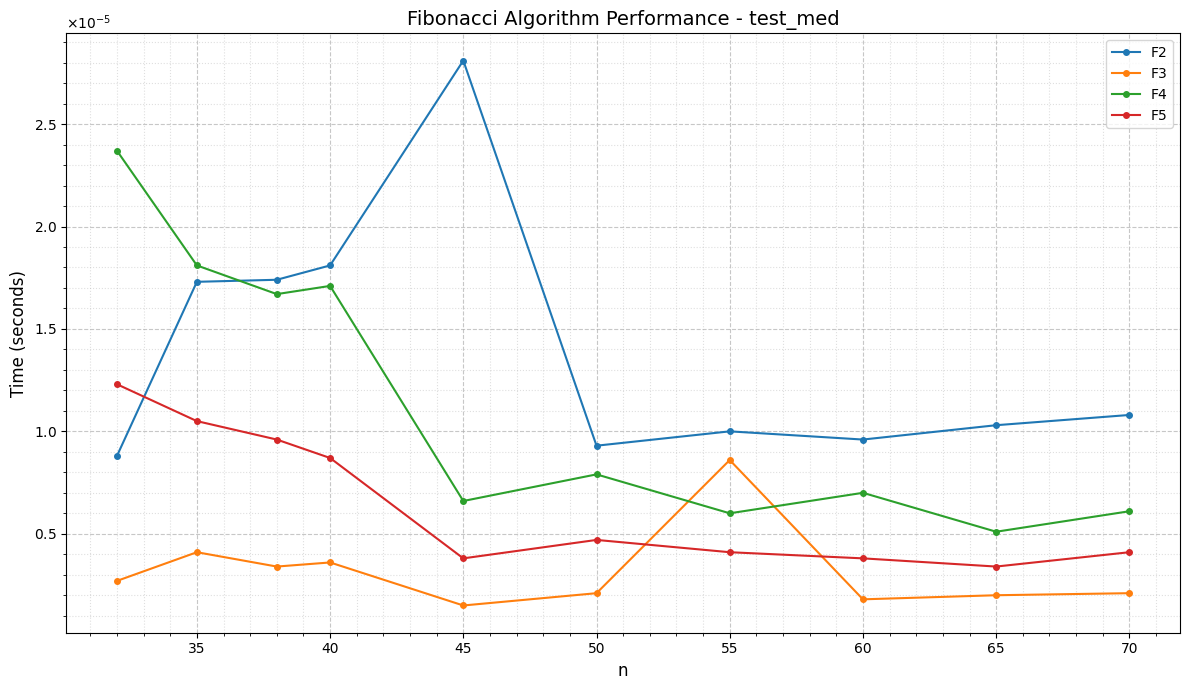


--- Summary for test_med ---
F2: avg=1.397000000000000e-05s, min=8.800000000000000e-06s, max=2.810000000000000e-05s
F3: avg=3.190000000000000e-06s, min=1.500000000000000e-06s, max=8.600000000000001e-06s
F4: avg=1.143000000000000e-05s, min=5.100000000000000e-06s, max=2.370000000000000e-05s
F5: avg=6.500000000000000e-06s, min=3.400000000000000e-06s, max=1.230000000000000e-05s

Running test_high with algorithms: ['F2', 'F3', 'F4', 'F5']


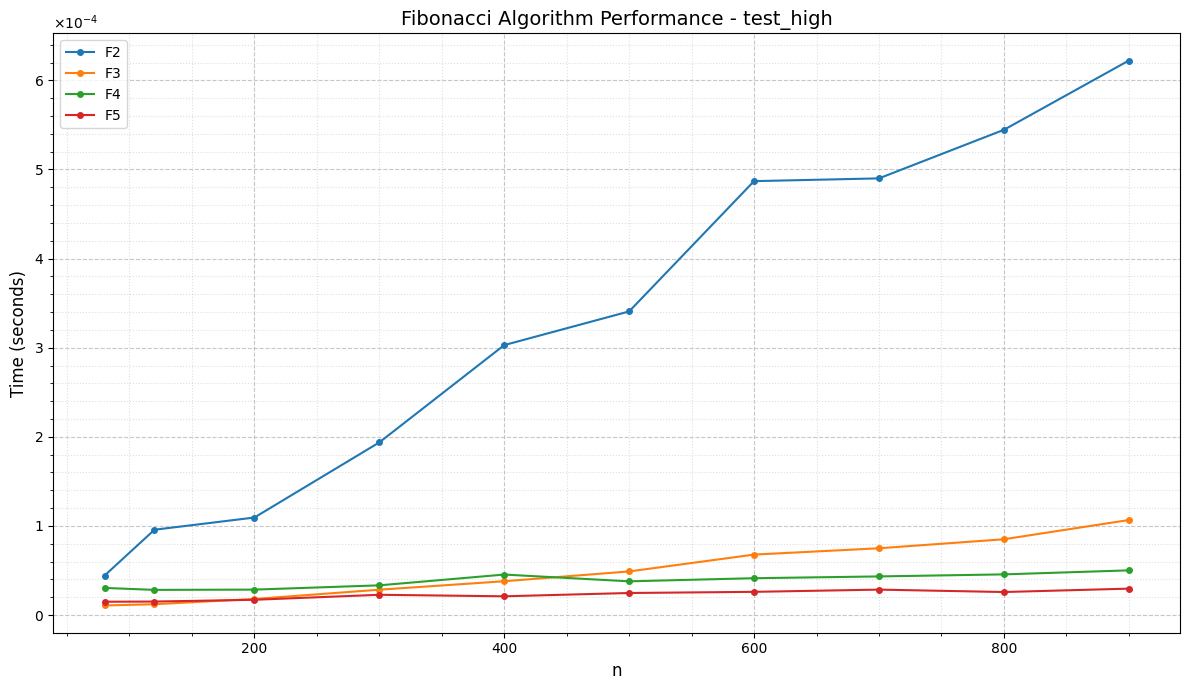


--- Summary for test_high ---
F2: avg=3.230200000000000e-04s, min=4.420000000000000e-05s, max=6.222000000000001e-04s
F3: avg=4.903000000000000e-05s, min=1.070000000000000e-05s, max=1.066000000000000e-04s
F4: avg=3.839000000000000e-05s, min=2.820000000000000e-05s, max=5.010000000000000e-05s
F5: avg=2.254000000000000e-05s, min=1.490000000000000e-05s, max=2.960000000000000e-05s

Running final_boss with algorithms: ['F3', 'F4', 'F4']


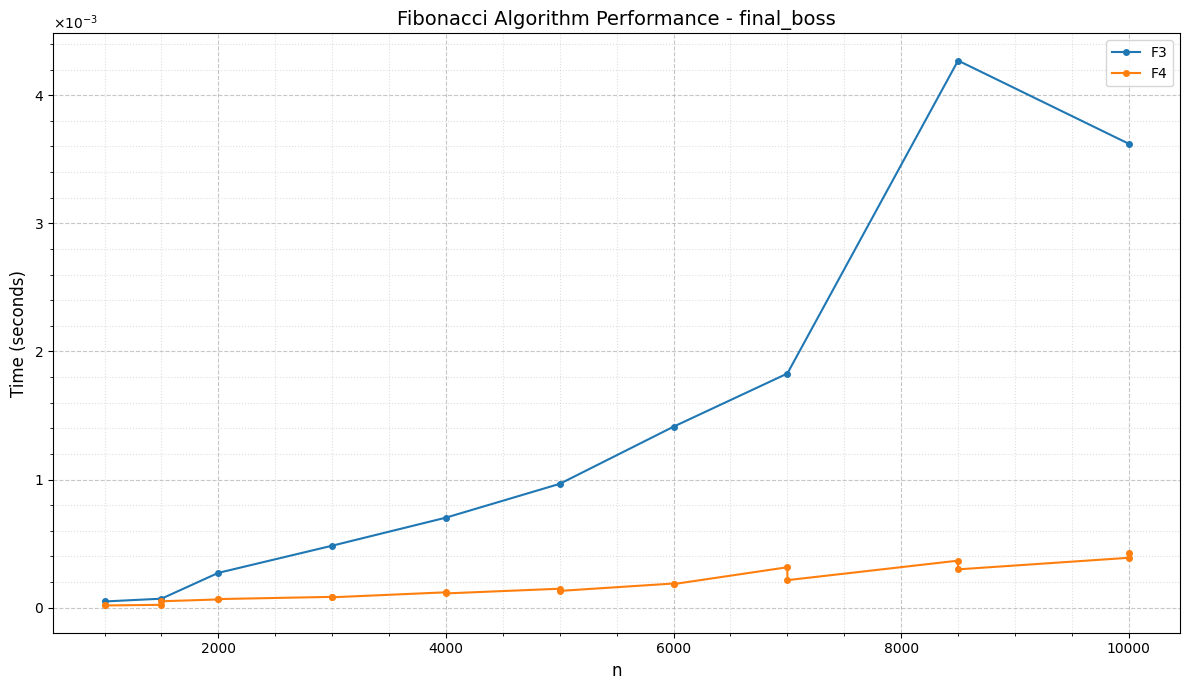


--- Summary for final_boss ---
F3: avg=1.367110000000000e-03s, min=4.810000000000000e-05s, max=4.269800000000000e-03s
F4: avg=1.650150000000000e-04s, min=1.680000000000000e-05s, max=4.273000000000000e-04s

Running final_boss (fastest: F4, F5) with algorithms: ['F4', 'F5']


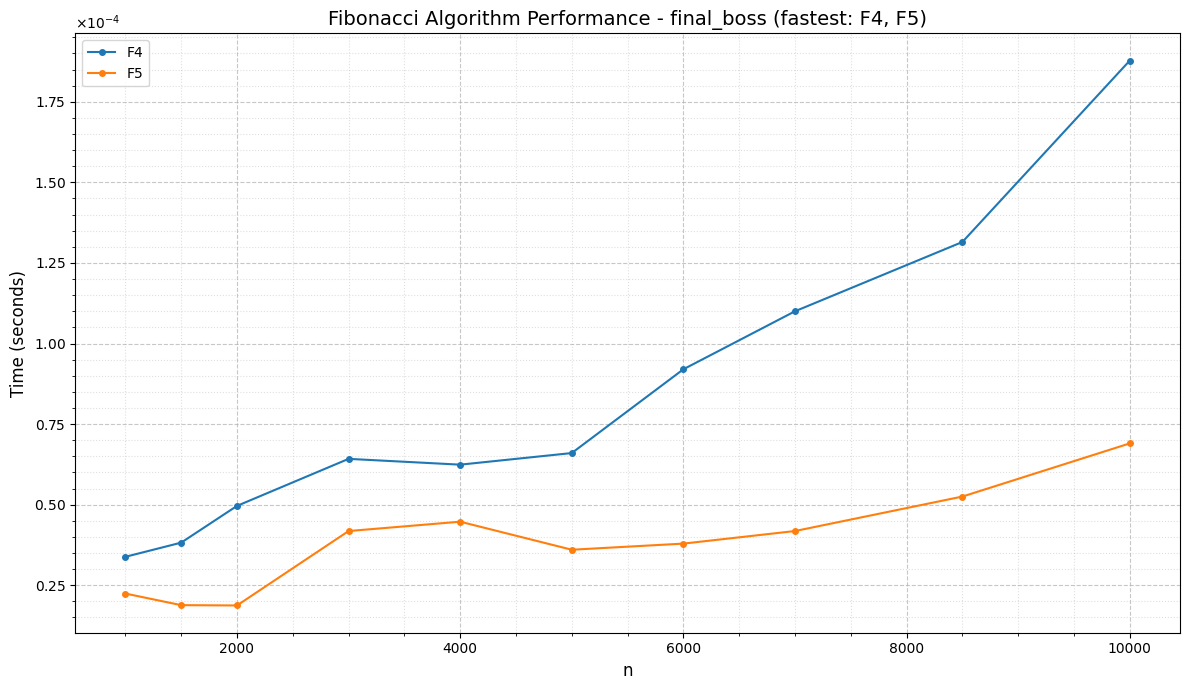


--- Summary for final_boss (fastest: F4, F5) ---
F4: avg=8.355000000000000e-05s, min=3.380000000000000e-05s, max=1.878000000000000e-04s
F5: avg=3.836000000000000e-05s, min=1.870000000000000e-05s, max=6.900000000000000e-05s


In [39]:
compute_print_and_plot_tests()